# Imports and Reading Data


In [26]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

df = pd.read_csv('store_sales.csv')

# Data Understanding

In [27]:
df.shape

(5000, 11)

In [28]:
df.head(10)

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10
5,6,48,Male,Groceries,Snacks,36.76,Autumn,Card,2.5,14,2
6,7,54,Male,Electronics,Mobile Phone,1396.16,Autumn,Card,4.7,18,4
7,8,59,Female,Beauty,Perfume,35.55,Summer,Card,4.6,14,7
8,9,51,Male,Electronics,Smart Watch,2238.79,Spring,Card,4.3,20,5
9,10,47,Female,Footwear,Formal Shoes,225.49,Spring,Card,4.7,18,4


In [29]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Category', 'ItemPurchased', 'Amount',
       'Season', 'PaymentMethod', 'ItemRating', 'DiscountApplied(%)',
       'PreviousPurchases'],
      dtype='str')

In [30]:
df.dtypes

CustomerID              int64
Age                     int64
Gender                    str
Category                  str
ItemPurchased             str
Amount                float64
Season                    str
PaymentMethod             str
ItemRating            float64
DiscountApplied(%)      int64
PreviousPurchases       int64
dtype: object

In [31]:
df.describe()

,CustomerID,Age,Amount,ItemRating,DiscountApplied(%),PreviousPurchases
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,45.224800,285.090522,3.784160,14.983600,5.008800
std,1443.520003,14.564995,551.454382,0.681796,5.988063,2.194285
min,1.000000,20.000000,5.080000,1.100000,0.000000,0.000000
25%,1250.750000,33.000000,70.547500,3.300000,11.000000,3.000000
50%,2500.500000,45.000000,122.485000,3.800000,15.000000,5.000000
75%,3750.250000,58.000000,184.535000,4.300000,19.000000,6.000000
max,5000.000000,70.000000,2997.940000,5.000000,36.000000,13.000000


# Data Prep

In [32]:
#We want to find out what factors influence what customers purchase
df = df[['CustomerID','Age','Gender','Category','ItemPurchased','Season']]

In [33]:
df.isna().sum()

CustomerID       0
Age              0
Gender           0
Category         0
ItemPurchased    0
Season           0
dtype: int64

In [34]:
df[df.duplicated()]

,CustomerID,Age,Gender,Category,ItemPurchased,Season


# Feature Understanding

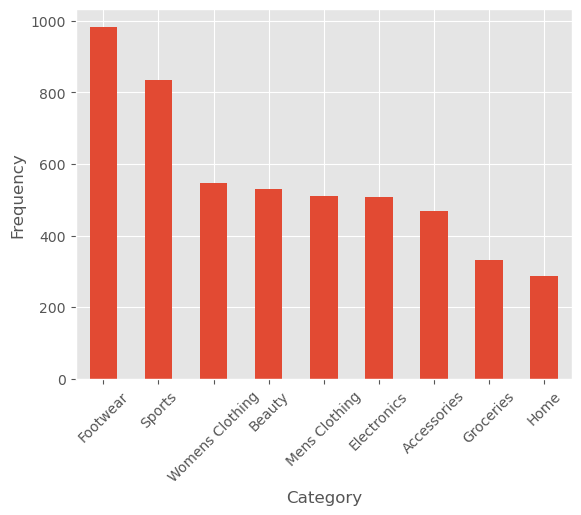

In [35]:
# Category
ax = df['Category'].value_counts().plot(kind='bar')
ax.tick_params(axis='x', labelrotation=45)
ax.set_ylabel("Frequency")
plt.show()

Footwear and Sports are the most frequently purchased product categories, indicating that customer demand is concentrated in these areas. In contrast, Home products represent the least frequently purchased category.

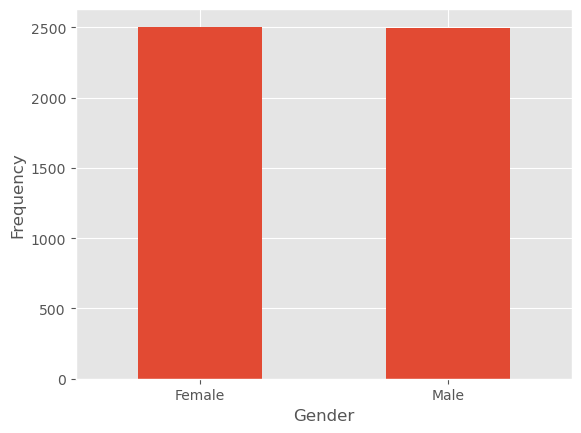

In [36]:
# Gender
ax = df['Gender'].value_counts().plot(kind = "bar")
ax.tick_params(axis = 'x', rotation = 0)
ax.set_ylabel("Frequency")
plt.show()


Male and female customers are represented in nearly equal proportions. This balanced distribution reduces the likelihood that later analyses will be biased by gender imbalance.

# Item Purchased

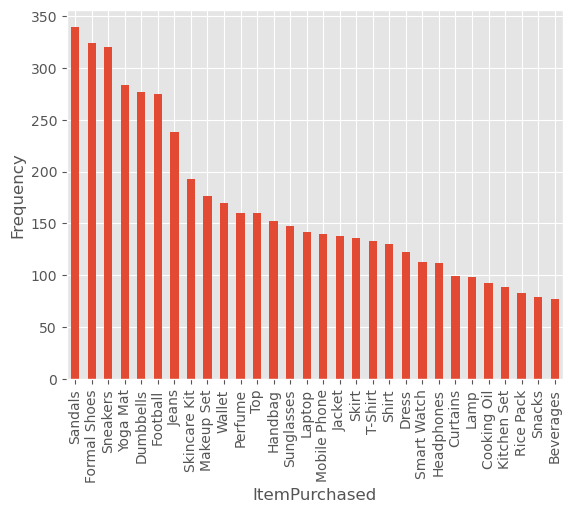

In [37]:
ax = df['ItemPurchased'].value_counts().plot(kind = 'bar')
ax.set_ylabel("Frequency")
plt.show()

Sandals, Formal Shoes, and Sneakers are the most frequently purchased items. This aligns with the earlier finding that Footwear is one of the most popular product categories. Beverages are among the least frequently purchased items.

# Season

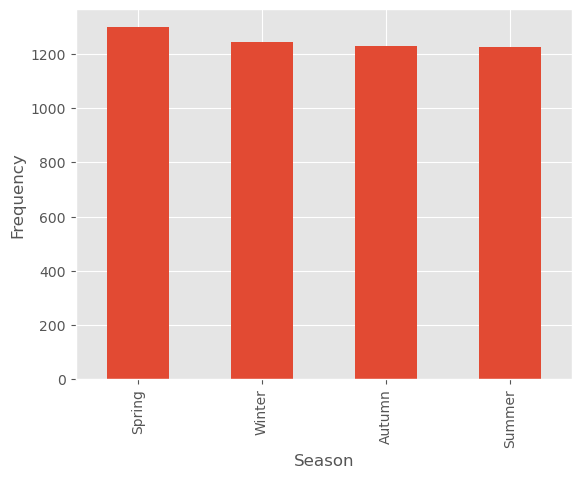

In [38]:
ax = df['Season'].value_counts().plot(kind = 'bar')
ax.set_ylabel("Frequency")
plt.show()

Purchases are relatively evenly distributed across seasons, although Spring exhibits a slightly higher purchase volume than the other seasons. This suggests that the dataset is not heavily skewed toward any particular season.

# Age

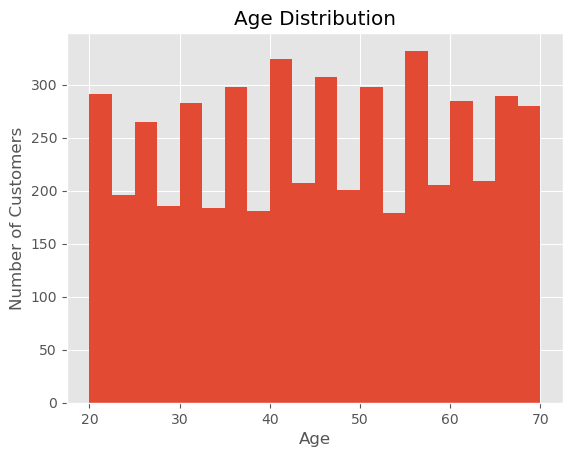

In [39]:
ax = df['Age'].hist(bins=20)
ax.set_xlabel('Age')
ax.set_ylabel('Number of Customers')
ax.set_title('Age Distribution')
plt.show()

The age distribution appears relatively uniform and does not show a strong peak or concentration around any particular age range. Instead, customer ages are spread relatively evenly throughout the dataset.

<Axes: >

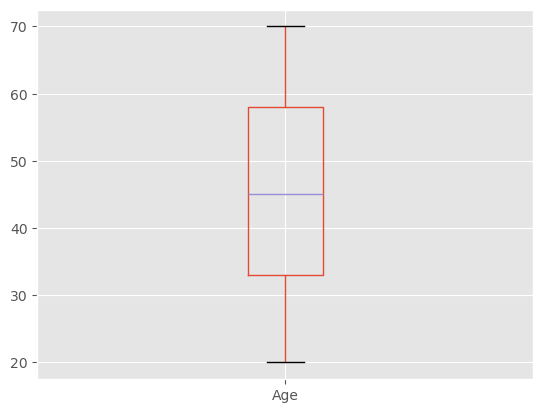

In [40]:
df.boxplot(column = 'Age')

No significant outliers in this dataset.

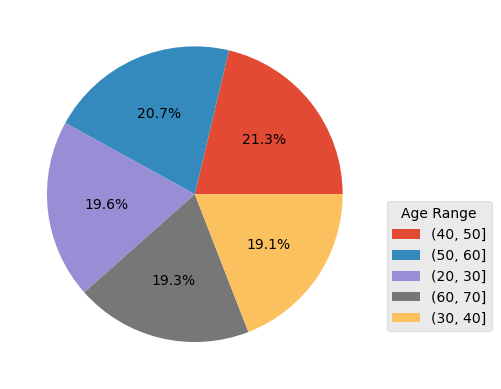

In [41]:
# Univariate Analysis on Age Range
df['AgeRange'] = pd.cut(df['Age'], bins = [20,30,40,50,60,70])
ax = df['AgeRange'].value_counts().plot(
    kind='pie',
    labels=None,
    autopct='%1.1f%%'
)

ax.legend(
    title='Age Range',
    labels=df['AgeRange'].value_counts().index,
    bbox_to_anchor=(1, 0.5)
)

ax.set_ylabel('')
plt.show()

The customer base appears to be evenly distributed across age groups. Customers aged 40-50 represents the largest segment at 21.3%. No age range dominates the dataset, suggesting that the retailer serves a broad range of ages. Since age groups are similarly sized, comparisons of spending behavior will less likely be biased by sample size differences

Overall, the customer base spans a wide range of ages from 20 to 70 years old. The age distribution is relatively uniform with no significant outliers or dominant age groups. Since the age groups are similarly represented, subsequent analyses comparing spending patterns across age groups are less likely to be influenced by sample sizes

# Feature Understanding Summary

The dataset contains a balanced representation of customers across genders, seasons, and age groups. Footwear and Sports are the most frequently purchased categories, with Sandals, Formal Shoes, and Sneakers emerging as the most popular individual products. The relatively even distribution of demographic and seasonal variables provides a solid foundation for investigating whether factors such as age, gender, and season influence customer purchasing preferences.

# Bivariate Analysis

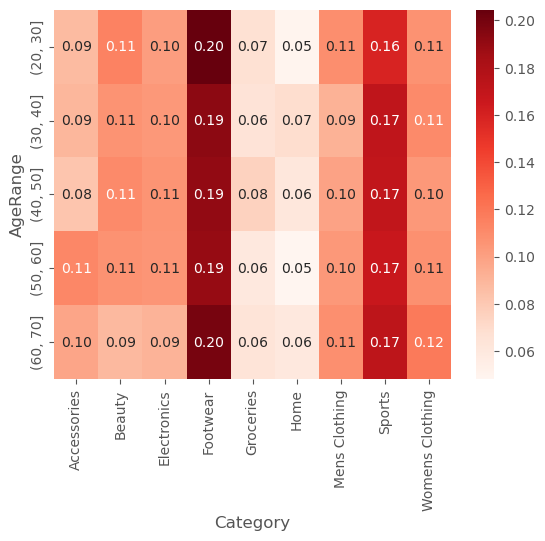

In [42]:
# Age Range v Category
ct_norm = pd.crosstab(
    df['AgeRange'],
    df['Category'],
    normalize='index'
)

sns.heatmap(
    ct_norm,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)
plt.show()

Visually, product category preferences appear relatively consistent across age groups. Footwear and Sports remain the most frequently purchased categories regardless of age, while categories such as Home and Groceries are consistently less popular. This suggests that age may not be a strong factor influencing product category preferences.

To statistically evaluate whether category preferences differ across age groups, a Chi-Square Test of Independence will be performed.

In [43]:
ct = pd.crosstab(
    df['AgeRange'],
    df['Category'],
    normalize='index'
)
chi2, p, dof, expected = chi2_contingency(ct)

print(p)

1.0


Our hypotheses to test is: \
$
H_0 : \text{Age Range and Product Category are independent.} \space vs \space H_a : \text{Age Range and Product Category are not independent.}
$

Conducting a Chi-Square Test of Independence at a 5% significance level gave a p-value of 1. Since the p-value is greater than $\alpha=0.05$, we fail to reject the null hypothesis. Therefore, there is insufficient evidence to suggest that product category preferences vary across age groups. This supports the visual observation that purchasing preferences appear relatively consistent regardless of age.

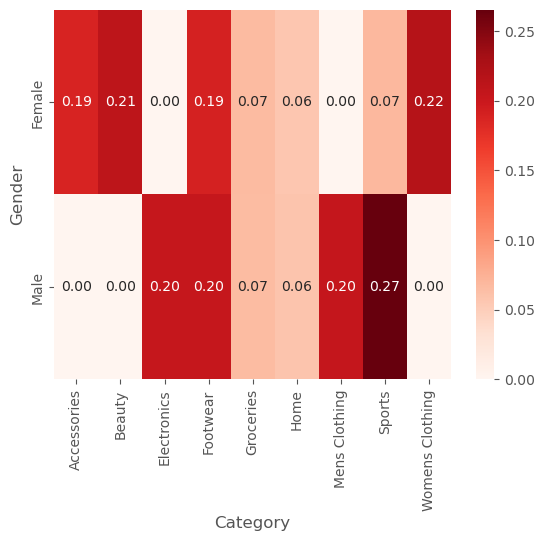

In [44]:
# Gender v category
ct_norm = pd.crosstab(
    df['Gender'],
    df['Category'],
    normalize='index'
)

sns.heatmap(
    ct_norm,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)
plt.show()

Visually, product category preferences appear to vary across genders. Female customers show stronger preferences for Accessories, Beauty, and Women's Clothing, whereas male customers exhibit stronger preferences for Electronics, Men's Clothing, and Sports. Both genders demonstrate similar purchasing rates within the Footwear category, which aligns with the earlier finding that Footwear is one of the most popular categories overall. These differences suggest that gender may be associated with product category preferences.

To statistically evaluate if gender does influence purchasing habits, a Chi-Square test of independence will be done

In [45]:
ct = pd.crosstab(
    df['Gender'],
    df['Category'],
)

chi2, p, dof, expected = chi2_contingency(ct)

print(p)

0.0


Our hypotheses to test is: \
$
H_0 : \text{Gender and Product Category are independent.} \space vs \space H_a : \text{Gender and Product Category are not independent.}
$

Conducting a Chi-Square Test of Independence at a 5% significance level gave a p-value $\approx$ 0. Since the p-value is less than $\alpha=0.05$, we reject the null hypothesis. Therefore, there is sufficient evidence to suggest that product category preferences vary across gender. This supports the visual observation that purchasing preferences appear vary across gender

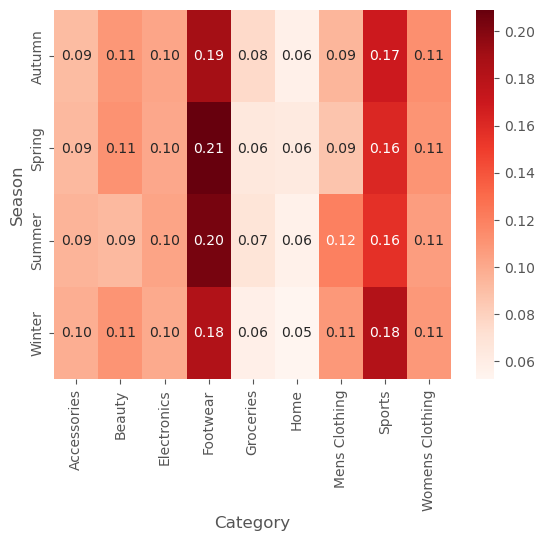

In [46]:
# Season v category
ct_norm = pd.crosstab(
    df['Season'],
    df['Category'],
    normalize='index'
)

sns.heatmap(
    ct_norm,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)
plt.show()

Visually, product category preferences appear relatively consistent across seasons. Footwear and Sports remain the most frequently purchased categories regardless of age, while categories such as Home and Groceries are consistently less popular. This suggests that saesons may not be a strong factor influencing product category preferences.

To statistically evaluate whether category preferences differ across seasons, a Chi-Square Test of Independence will be performed.

In [47]:
ct = pd.crosstab(
    df['Season'],
    df['Category'],
)

chi2, p, dof, expected = chi2_contingency(ct)

print(p)

0.6039849662187782


Our hypotheses to test is: \
$
H_0 : \text{Seasons and Product Category are independent.} \space vs \space H_a : \text{Seasons and Product Category are not independent.}
$

Conducting a Chi-Square Test of Independence at a 5% significance level gave a p-value of 0.603. Since the p-value is greater than $\alpha=0.05$, we fail to reject the null hypothesis. Therefore, there is insufficient evidence to suggest that product category preferences vary across seasons. This supports the visual observation that purchasing preferences appear relatively consistent regardless of season.

Although no association was found between age group and product category preferences, categories represent broad classifications of products. To determine whether age influences preferences for specific products within these categories, the relationship between Age Range and Item Purchased will be explored.

In [48]:
ct = pd.crosstab(df['AgeRange'], df['ItemPurchased'])
chi2, p, dof, expected = chi2_contingency(ct)
print(p)

0.8370950770422126


Our hypotheses to test is: \
$
H_0 : \text{Age Range and Item Purchased are independent.} \space vs \space H_a : \text{Age Range and Item Purchased are not independent.}
$

Conducting a Chi-Square Test of Independence at a 5% significance level gave a p-value of 0.837. Since the p-value is greater than $\alpha=0.05$, we fail to reject the null hypothesis. Therefore, there is insufficient evidence to suggest that purchased item preferences vary across ages.

We will perform the same test with Seasons to determine whether seasons influences preferences for specific products within these categories, the relationship between Season and Item Purchased will be explored

In [49]:
ct = pd.crosstab(df['Season'], df['ItemPurchased'])
chi2, p, dof, expected = chi2_contingency(ct)
print(p)

0.3149471520020708


Our hypotheses to test is: \
$
H_0 : \text{Season and Item Purchased are independent.} \space vs \space H_a : \text{Season and Item Purchased are not independent.}
$

Conducting a Chi-Square Test of Independence at a 5% significance level gave a p-value of 0.314. Since the p-value is less than $\alpha=0.05$, we reject the null hypothesis. Therefore, there is sufficient evidence to suggest that purchased item preferences vary across ages.

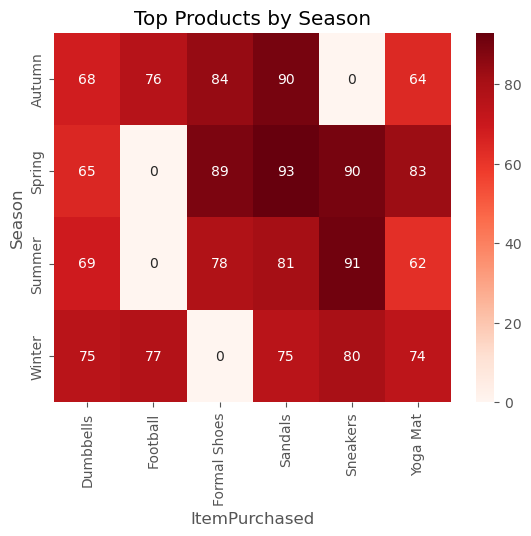

In [50]:
top5 = (
    df.groupby('Season')['ItemPurchased']
      .value_counts()
      .groupby(level=0)
      .head(5)
      .reset_index(name='Count')
)

pivot = top5.pivot(
    index='Season',
    columns='ItemPurchased',
    values='Count'
).fillna(0)

sns.heatmap(
    pivot,
    annot=True,
    cmap='Reds',
    fmt='.0f'
)
plt.title('Top Products by Season')
plt.show()

Consistent with the Chi-Square Test of Independence, product preferences appear to vary across seasons. While Sandals remain one of the most popular products throughout the year, the composition of the top purchased items changes by season. For example, Football appears among the top products in Autumn and Winter but does not appear among the top-selling products in Spring or Summer. Similarly, Sneakers are particularly popular during Spring and Summer. These findings suggest that season influences preferences for specific products, even though broad product category preferences were found to be independent of season.

# Key Findings

1. Age Range and Product Category
   - No significant association was found (p = 0.8885).
   - Product category preferences appear consistent across age groups.

2. Gender and Product Category
   - A significant association was found (p < 0.001).
   - Male and female customers exhibit different product category preferences.

3. Season and Product Category
   - No significant association was found.
   - Broad category preferences remain consistent across seasons.

4. Age Range and Item Purchased
   - No significant association was found.
   - Age does influence broad categories or specific items purchased

5. Season and Item Purchased
   - A significant association was found.
   - Seasonal effects appear at the product level rather than the category level.

# Conclusion
The objective of this analysis was to determine which factors influence customer purchasing preferences. Chi-Square Tests of Independence revealed that gender is associated with product category preferences, whereas age range and season are not. However, when product preferences were examined at the item level, age range exhibited no significant associations with the products customers purchased, whereas seasons did exhibit significant associations. These findings suggest that customer purchasing preferences are better explained by specific product choices rather than broad product categories. Overall, gender and season appear to influence purchasing behavior, although their effects vary depending on the level of detail examined.